In [7]:
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =====================================================
# USER INPUTS
# =====================================================

MODEL_WEIGHTS = Path(r"../runs/final_model_benchmark_09_06_2026/convnext_base/best_model.pth")
IMAGE_PATH = Path(r"../data/images/megu.jpg")

MODEL_ARCH = "convnext_base"

CLASS_NAMES = [
    "a_bikes",
    "b_moto",
    "c_pass",
    "d_light_comm",
    "e_heavy_rigid",
    "f_articulated",
    "g_bus",
    "h_agri",
]

NUM_CLASSES = len(CLASS_NAMES)

OUTPUT_DIR = Path("./inference_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
# =====================================================
# MODEL LOADING
# =====================================================

def build_model(arch: str, num_classes: int) -> nn.Module:
    """
    Build the same classifier architecture used during training.
    Extend this function if you want to test other backbones.
    """
    if arch == "convnext_base":
        model = models.convnext_base(weights=None)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
        return model

    elif arch == "convnext_small":
        model = models.convnext_small(weights=None)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
        return model

    elif arch == "convnext_tiny":
        model = models.convnext_tiny(weights=None)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
        return model

    else:
        raise ValueError(f"Unsupported MODEL_ARCH: {arch}")

In [9]:
def extract_state_dict(checkpoint):
    """
    Handles common checkpoint formats:
    - raw state_dict
    - {'model_state_dict': ...}
    - {'state_dict': ...}
    - full torch.nn.Module object
    """
    if isinstance(checkpoint, nn.Module):
        return checkpoint.state_dict()

    if isinstance(checkpoint, dict):
        for key in ["model_state_dict", "state_dict", "model"]:
            if key in checkpoint:
                value = checkpoint[key]
                if isinstance(value, nn.Module):
                    return value.state_dict()
                return value

    return checkpoint


def clean_state_dict_keys(state_dict):
    """
    Removes common prefixes created by DataParallel or wrapped training modules.
    """
    cleaned = {}
    for key, value in state_dict.items():
        new_key = key

        for prefix in ["module.", "model."]:
            if new_key.startswith(prefix):
                new_key = new_key[len(prefix):]

        cleaned[new_key] = value

    return cleaned


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(MODEL_ARCH, NUM_CLASSES)

checkpoint = torch.load(MODEL_WEIGHTS, map_location=device)
state_dict = extract_state_dict(checkpoint)
state_dict = clean_state_dict_keys(state_dict)

load_result = model.load_state_dict(state_dict, strict=False)

print("Missing keys:", load_result.missing_keys)
print("Unexpected keys:", load_result.unexpected_keys)

model = model.to(device)
model.eval()

print(f"Loaded model: {MODEL_ARCH}")
print(f"Device: {device}")


Missing keys: []
Unexpected keys: []
Loaded model: convnext_base
Device: cuda



Predicted class: c_pass
Probability: 0.9252 (92.52%)


,class,probability,probability_percent
2,c_pass,0.925222,92.522186
7,h_agri,0.011474,1.147445
6,g_bus,0.010999,1.099890
0,a_bikes,0.010916,1.091606
1,b_moto,0.010811,1.081143
5,f_articulated,0.010522,1.052203
3,d_light_comm,0.010073,1.007264
4,e_heavy_rigid,0.009983,0.998278


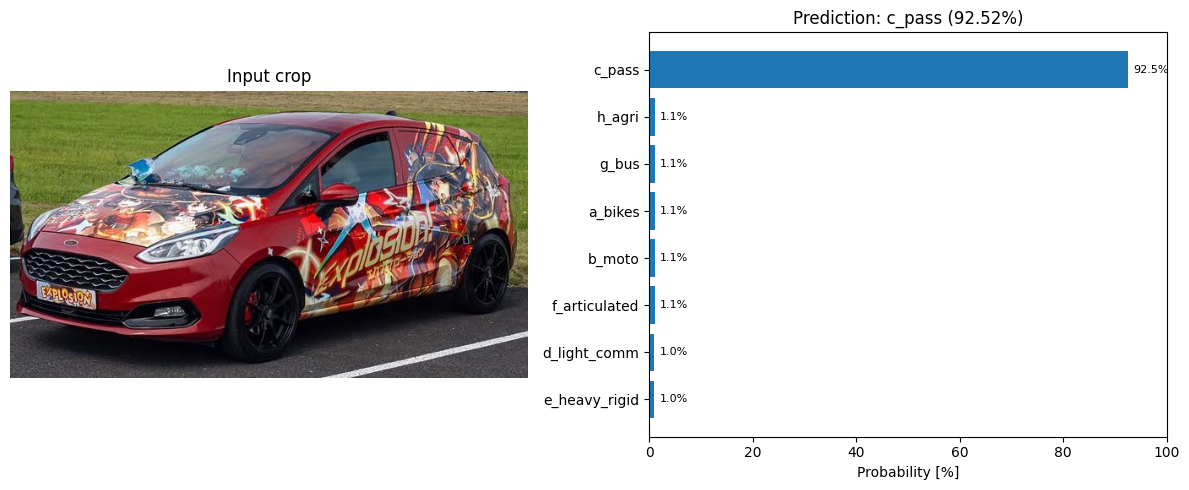


Saved figure to: inference_outputs/megu_classification_probabilities.png
Saved probabilities to: inference_outputs/megu_classification_probabilities.csv


In [10]:
# =====================================================
# IMAGE PREPROCESSING
# =====================================================

# Matches the validation/inference-style preprocessing:
# resize -> center crop -> ImageNet normalization.
preprocess = transforms.Compose([
    transforms.Resize((236, 236)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

image = Image.open(IMAGE_PATH).convert("RGB")
input_tensor = preprocess(image).unsqueeze(0).to(device)


# =====================================================
# INFERENCE
# =====================================================

with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

pred_idx = int(np.argmax(probs))
pred_class = CLASS_NAMES[pred_idx]
pred_prob = float(probs[pred_idx])

results_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "probability": probs,
    "probability_percent": probs * 100,
}).sort_values("probability", ascending=False)

print(f"\nPredicted class: {pred_class}")
print(f"Probability: {pred_prob:.4f} ({pred_prob * 100:.2f}%)")
display(results_df)


# =====================================================
# VISUALIZATION FOR THESIS FIGURE
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Input image
axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title("Input crop")

# Probability bar chart
plot_df = results_df.sort_values("probability", ascending=True)

axes[1].barh(plot_df["class"], plot_df["probability_percent"])
axes[1].set_xlabel("Probability [%]")
axes[1].set_xlim(0, 100)
axes[1].set_title(f"Prediction: {pred_class} ({pred_prob * 100:.2f}%)")

for y, value in enumerate(plot_df["probability_percent"]):
    axes[1].text(value + 1, y, f"{value:.1f}%", va="center", fontsize=8)

plt.tight_layout()

figure_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_classification_probabilities.png"
csv_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_classification_probabilities.csv"

plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

results_df.to_csv(csv_path, index=False)

print(f"\nSaved figure to: {figure_path}")
print(f"Saved probabilities to: {csv_path}")